Dane do analizy:  

https://www.kaggle.com/datasets/lucasgreenwell/depression-anxiety-stress-scales-responses

# Zadanie: załadować dane do df

In [ ]:
!kaggle datasets download lucasgreenwell/depression-anxiety-stress-scales-responses

Dataset URL: https://www.kaggle.com/datasets/lucasgreenwell/depression-anxiety-stress-scales-responses
License(s): DbCL-1.0
  0% 0.00/7.93M [00:00<?, ?B/s]
100% 7.93M/7.93M [00:00<00:00, 87.2MB/s]


In [ ]:
!unzip depression-anxiety-stress-scales-responses.zip

Archive:  depression-anxiety-stress-scales-responses.zip
  inflating: codebook.txt            
  inflating: data.csv                
  inflating: demo1.png               


In [ ]:
import pandas as pd

In [ ]:
df_DASSR = pd.read_csv("data.csv")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 438, saw 2


In [ ]:
with open('data.csv') as f:
    lines = f.readlines()

In [ ]:
lines[0:3]

['Q1A\tQ1I\tQ1E\tQ2A\tQ2I\tQ2E\tQ3A\tQ3I\tQ3E\tQ4A\tQ4I\tQ4E\tQ5A\tQ5I\tQ5E\tQ6A\tQ6I\tQ6E\tQ7A\tQ7I\tQ7E\tQ8A\tQ8I\tQ8E\tQ9A\tQ9I\tQ9E\tQ10A\tQ10I\tQ10E\tQ11A\tQ11I\tQ11E\tQ12A\tQ12I\tQ12E\tQ13A\tQ13I\tQ13E\tQ14A\tQ14I\tQ14E\tQ15A\tQ15I\tQ15E\tQ16A\tQ16I\tQ16E\tQ17A\tQ17I\tQ17E\tQ18A\tQ18I\tQ18E\tQ19A\tQ19I\tQ19E\tQ20A\tQ20I\tQ20E\tQ21A\tQ21I\tQ21E\tQ22A\tQ22I\tQ22E\tQ23A\tQ23I\tQ23E\tQ24A\tQ24I\tQ24E\tQ25A\tQ25I\tQ25E\tQ26A\tQ26I\tQ26E\tQ27A\tQ27I\tQ27E\tQ28A\tQ28I\tQ28E\tQ29A\tQ29I\tQ29E\tQ30A\tQ30I\tQ30E\tQ31A\tQ31I\tQ31E\tQ32A\tQ32I\tQ32E\tQ33A\tQ33I\tQ33E\tQ34A\tQ34I\tQ34E\tQ35A\tQ35I\tQ35E\tQ36A\tQ36I\tQ36E\tQ37A\tQ37I\tQ37E\tQ38A\tQ38I\tQ38E\tQ39A\tQ39I\tQ39E\tQ40A\tQ40I\tQ40E\tQ41A\tQ41I\tQ41E\tQ42A\tQ42I\tQ42E\tcountry\tsource\tintroelapse\ttestelapse\tsurveyelapse\tTIPI1\tTIPI2\tTIPI3\tTIPI4\tTIPI5\tTIPI6\tTIPI7\tTIPI8\tTIPI9\tTIPI10\tVCL1\tVCL2\tVCL3\tVCL4\tVCL5\tVCL6\tVCL7\tVCL8\tVCL9\tVCL10\tVCL11\tVCL12\tVCL13\tVCL14\tVCL15\tVCL16\teducation\turban\tgender\tengnat\tage\t

In [ ]:
df_DASSR = pd.read_csv("data.csv", sep='\t')

In [ ]:
df_DASSR.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology


# Przygotowanie danych do PCA

## Wybieramy zmienne do PCA

In [ ]:
df_DASSR.columns

Index(['Q1A', 'Q1I', 'Q1E', 'Q2A', 'Q2I', 'Q2E', 'Q3A', 'Q3I', 'Q3E', 'Q4A',
       ...
       'screensize', 'uniquenetworklocation', 'hand', 'religion',
       'orientation', 'race', 'voted', 'married', 'familysize', 'major'],
      dtype='object', length=172)

In [ ]:
df_qa = 1  #  Q1A - Q42A

In [ ]:
df_DASSR['Q1A'].value_counts()

,count
Q1A,
2,13320
4,10393
3,9958
1,6104


In [ ]:
col_to_del = []
for col in df_DASSR.columns:
  if not col.startswith('Q'):
    col_to_del.append(col)
  elif col.startswith('Q') and not col.endswith('A'):
    col_to_del.append(col)
col_to_del

['Q1I',
 'Q1E',
 'Q2I',
 'Q2E',
 'Q3I',
 'Q3E',
 'Q4I',
 'Q4E',
 'Q5I',
 'Q5E',
 'Q6I',
 'Q6E',
 'Q7I',
 'Q7E',
 'Q8I',
 'Q8E',
 'Q9I',
 'Q9E',
 'Q10I',
 'Q10E',
 'Q11I',
 'Q11E',
 'Q12I',
 'Q12E',
 'Q13I',
 'Q13E',
 'Q14I',
 'Q14E',
 'Q15I',
 'Q15E',
 'Q16I',
 'Q16E',
 'Q17I',
 'Q17E',
 'Q18I',
 'Q18E',
 'Q19I',
 'Q19E',
 'Q20I',
 'Q20E',
 'Q21I',
 'Q21E',
 'Q22I',
 'Q22E',
 'Q23I',
 'Q23E',
 'Q24I',
 'Q24E',
 'Q25I',
 'Q25E',
 'Q26I',
 'Q26E',
 'Q27I',
 'Q27E',
 'Q28I',
 'Q28E',
 'Q29I',
 'Q29E',
 'Q30I',
 'Q30E',
 'Q31I',
 'Q31E',
 'Q32I',
 'Q32E',
 'Q33I',
 'Q33E',
 'Q34I',
 'Q34E',
 'Q35I',
 'Q35E',
 'Q36I',
 'Q36E',
 'Q37I',
 'Q37E',
 'Q38I',
 'Q38E',
 'Q39I',
 'Q39E',
 'Q40I',
 'Q40E',
 'Q41I',
 'Q41E',
 'Q42I',
 'Q42E',
 'country',
 'source',
 'introelapse',
 'testelapse',
 'surveyelapse',
 'TIPI1',
 'TIPI2',
 'TIPI3',
 'TIPI4',
 'TIPI5',
 'TIPI6',
 'TIPI7',
 'TIPI8',
 'TIPI9',
 'TIPI10',
 'VCL1',
 'VCL2',
 'VCL3',
 'VCL4',
 'VCL5',
 'VCL6',
 'VCL7',
 'VCL8',
 'VCL9',
 'VCL10',

In [ ]:
selected_columns = df_DASSR.loc[:, df_DASSR.columns.str.startswith("Q") & df_DASSR.columns.str.endswith("A")]
selected_columns

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A
0,4,4,2,4,4,4,4,4,2,1,...,2,3,4,4,1,2,4,3,4,4
1,4,1,2,3,4,4,3,4,3,2,...,3,2,2,3,4,2,2,1,2,2
2,3,1,4,1,4,3,1,3,2,4,...,1,4,3,4,4,4,2,2,1,4
3,2,3,2,1,3,3,4,2,3,3,...,2,4,1,1,2,1,3,4,4,2
4,2,2,3,4,4,2,4,4,4,3,...,4,4,3,4,3,3,3,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39770,2,1,3,2,3,2,1,3,1,4,...,2,4,1,2,4,4,2,3,1,3
39771,3,4,3,4,3,4,4,4,3,4,...,3,4,3,3,3,4,3,3,3,4
39772,2,1,2,1,1,1,1,1,2,1,...,2,1,1,1,1,1,2,1,1,1
39773,3,1,2,2,3,3,3,4,3,1,...,4,2,3,2,1,2,3,2,4,3


In [ ]:
[col for col in df_DASSR.columns if 'Q' == col[0] and 'A' == col[-1]]

['Q1A',
 'Q2A',
 'Q3A',
 'Q4A',
 'Q5A',
 'Q6A',
 'Q7A',
 'Q8A',
 'Q9A',
 'Q10A',
 'Q11A',
 'Q12A',
 'Q13A',
 'Q14A',
 'Q15A',
 'Q16A',
 'Q17A',
 'Q18A',
 'Q19A',
 'Q20A',
 'Q21A',
 'Q22A',
 'Q23A',
 'Q24A',
 'Q25A',
 'Q26A',
 'Q27A',
 'Q28A',
 'Q29A',
 'Q30A',
 'Q31A',
 'Q32A',
 'Q33A',
 'Q34A',
 'Q35A',
 'Q36A',
 'Q37A',
 'Q38A',
 'Q39A',
 'Q40A',
 'Q41A',
 'Q42A']

In [ ]:
[col for col in df_DASSR.columns if 'Q' in col and 'A' in col]

['Q1A',
 'Q2A',
 'Q3A',
 'Q4A',
 'Q5A',
 'Q6A',
 'Q7A',
 'Q8A',
 'Q9A',
 'Q10A',
 'Q11A',
 'Q12A',
 'Q13A',
 'Q14A',
 'Q15A',
 'Q16A',
 'Q17A',
 'Q18A',
 'Q19A',
 'Q20A',
 'Q21A',
 'Q22A',
 'Q23A',
 'Q24A',
 'Q25A',
 'Q26A',
 'Q27A',
 'Q28A',
 'Q29A',
 'Q30A',
 'Q31A',
 'Q32A',
 'Q33A',
 'Q34A',
 'Q35A',
 'Q36A',
 'Q37A',
 'Q38A',
 'Q39A',
 'Q40A',
 'Q41A',
 'Q42A']

In [ ]:
df_qa = df_DASSR[[col for col in df_DASSR.columns if 'Q' in col and 'A' in col]]
df_qa.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A
0,4,4,2,4,4,4,4,4,2,1,...,2,3,4,4,1,2,4,3,4,4
1,4,1,2,3,4,4,3,4,3,2,...,3,2,2,3,4,2,2,1,2,2
2,3,1,4,1,4,3,1,3,2,4,...,1,4,3,4,4,4,2,2,1,4
3,2,3,2,1,3,3,4,2,3,3,...,2,4,1,1,2,1,3,4,4,2
4,2,2,3,4,4,2,4,4,4,3,...,4,4,3,4,3,3,3,4,4,3


##  Skalowanie zmiennych

In [ ]:
df_qa.describe().T

,count,mean,std,min,25%,50%,75%,max
Q1A,39775.0,2.619485,1.032117,1.0,2.0,3.0,4.0,4.0
Q2A,39775.0,2.172269,1.111563,1.0,1.0,2.0,3.0,4.0
Q3A,39775.0,2.226097,1.038526,1.0,1.0,2.0,3.0,4.0
Q4A,39775.0,1.950170,1.042218,1.0,1.0,2.0,3.0,4.0
Q5A,39775.0,2.521458,1.069908,1.0,2.0,2.0,3.0,4.0
Q6A,39775.0,2.540214,1.049672,1.0,2.0,2.0,3.0,4.0
Q7A,39775.0,1.924928,1.033528,1.0,1.0,2.0,3.0,4.0
Q8A,39775.0,2.480427,1.052436,1.0,2.0,2.0,3.0,4.0
Q9A,39775.0,2.669591,1.067866,1.0,2.0,3.0,4.0,4.0
Q10A,39775.0,2.447316,1.139350,1.0,1.0,2.0,4.0,4.0


In [ ]:
df_qa_scaled = 1

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
df_qa_scaled = scaler.fit_transform(df_qa)

In [ ]:
pd.DataFrame(df_qa_scaled, columns=df_qa.columns).describe().T  #  sprawdzenie standaryzacji

,count,mean,std,min,25%,50%,75%,max
Q1A,39775.0,1.714949e-17,1.000013,-1.569109,-0.600215,0.368679,1.337573,1.337573
Q2A,39775.0,6.573972e-17,1.000013,-1.054627,-1.054627,-0.154981,0.744665,1.644310
Q3A,39775.0,-1.672075e-16,1.000013,-1.180627,-1.180627,-0.217712,0.745203,1.708118
Q4A,39775.0,-4.215917e-17,1.000013,-0.911692,-0.911692,0.047812,1.007317,1.966821
Q5A,39775.0,4.573198e-17,1.000013,-1.422063,-0.487392,-0.487392,0.447279,1.381951
Q6A,39775.0,-1.200464e-16,1.000013,-1.467347,-0.514657,-0.514657,0.438034,1.390725
Q7A,39775.0,8.288921e-17,1.000013,-0.894934,-0.894934,0.072638,1.040209,2.007781
Q8A,39775.0,-1.329086e-16,1.000013,-1.406685,-0.456497,-0.456497,0.493692,1.443881
Q9A,39775.0,1.550600e-16,1.000013,-1.563504,-0.627045,0.309414,1.245873,1.245873
Q10A,39775.0,-7.717271e-17,1.000013,-1.270316,-1.270316,-0.392611,1.362798,1.362798


# Analiza PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA()
numpy_pca = pca.fit_transform(df_qa_scaled)

In [ ]:
pca_desc = pd.DataFrame(numpy_pca).describe().T  #  zadanie: wykres: x - numer skladowej: od 1 do 42, y - wariancja (std**2)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
pca_desc['std']**2

,std
0,18.965334
1,2.860213
2,1.640158
3,1.107640
4,0.989788
5,0.837057
6,0.738744
7,0.690050
8,0.649546
9,0.612923


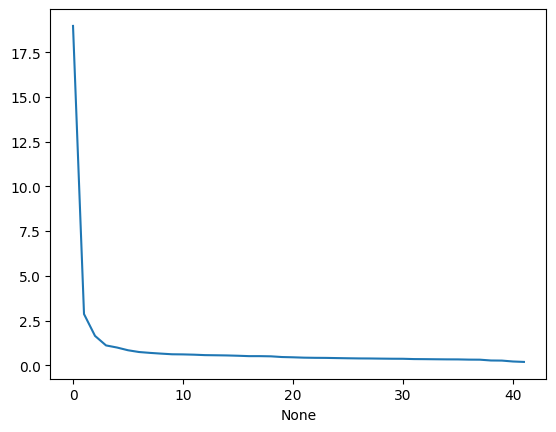

In [ ]:
sns.lineplot(x=pca_desc.index, y=[n**2 for n in pca_desc['std']])
plt.show()

In [ ]:
numpy_pca_df = pca_desc

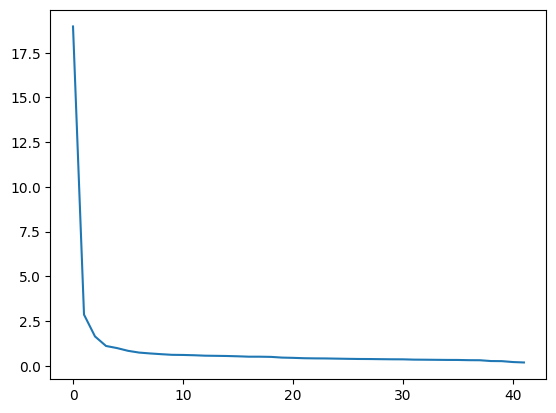

In [ ]:
plt.plot(numpy_pca_df.index, numpy_pca_df['std']**2)
plt.show()

In [ ]:
numpy_pca_df['std']**2

,std
0,18.965334
1,2.860213
2,1.640158
3,1.107640
4,0.989788
5,0.837057
6,0.738744
7,0.690050
8,0.649546
9,0.612923


In [ ]:
pca.explained_variance_

array([18.96533407,  2.86021296,  1.64015803,  1.10763985,  0.98978839,
        0.83705725,  0.73874436,  0.69005037,  0.64954617,  0.61292334,
        0.60541728,  0.58963888,  0.5649514 ,  0.55666329,  0.5470894 ,
        0.53020762,  0.50830097,  0.5080285 ,  0.49761029,  0.45819578,
        0.44355858,  0.42304103,  0.41410707,  0.41006252,  0.39922101,
        0.38918775,  0.38057639,  0.37725974,  0.3695661 ,  0.36320109,
        0.36066314,  0.34405143,  0.33984613,  0.3334564 ,  0.32766707,
        0.32567593,  0.31354679,  0.3100046 ,  0.2651995 ,  0.25937312,
        0.2092053 ,  0.18502707])

In [ ]:
pca.explained_variance_ratio_*100

array([45.15442202,  6.80985965,  3.90503998,  2.63717144,  2.35657978,
        1.99294335,  1.75887092,  1.64293578,  1.54649961,  1.45930459,
        1.44143348,  1.4038668 ,  1.34508857,  1.32535547,  1.30256106,
        1.26236735,  1.21020997,  1.20956126,  1.18475662,  1.0909149 ,
        1.05606531,  1.00721523,  0.98594443,  0.97631478,  0.95050233,
        0.92661421,  0.90611149,  0.89821489,  0.87989716,  0.86474275,
        0.85870017,  0.81914947,  0.80913711,  0.79392385,  0.78014007,
        0.7753994 ,  0.74652122,  0.73808763,  0.6314115 ,  0.61753952,
        0.49809533,  0.44052956])

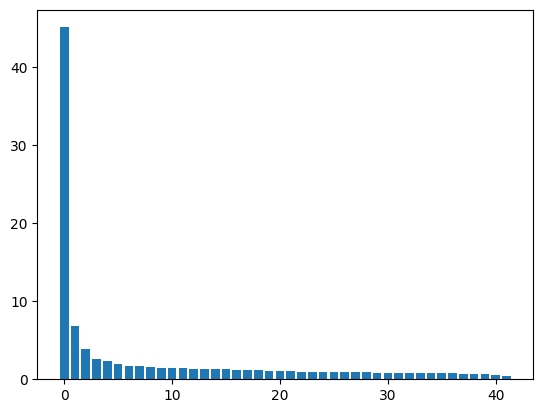

In [ ]:
plt.bar(x=numpy_pca_df.index, height=pca.explained_variance_ratio_*100)
plt.show()

### Korelacje pomiędzy PCA

In [ ]:
df_pca = pd.DataFrame(numpy_pca)

In [ ]:
df_pca.corr()

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,1.000000e+00,1.842628e-16,-3.951998e-16,-1.515884e-16,3.050022e-16,1.328110e-16,8.269983e-16,-1.510771e-16,5.239353e-16,5.925708e-16,...,-5.625199e-16,2.698509e-16,-3.094392e-16,3.557065e-16,8.427046e-17,-1.027870e-15,1.582288e-16,-1.894828e-16,-5.917170e-18,3.839759e-16
1,1.842628e-16,1.000000e+00,1.089640e-15,-3.064858e-16,-6.711461e-16,-6.431406e-17,-2.465640e-16,5.648617e-16,-8.443576e-16,-3.783855e-16,...,1.790111e-16,6.348686e-16,3.627238e-16,-8.794824e-16,6.672890e-16,-3.179401e-16,8.251287e-16,-9.592168e-16,-1.033305e-15,-6.507211e-16
2,-3.951998e-16,1.089640e-15,1.000000e+00,2.351909e-16,1.434962e-16,-4.602209e-16,-2.836820e-16,-1.633514e-16,6.570624e-16,-1.204726e-15,...,-3.183909e-16,-9.534290e-17,2.627175e-16,3.341634e-17,-8.989594e-16,-8.795651e-16,1.605229e-15,1.170442e-15,-6.061781e-16,9.947208e-16
3,-1.515884e-16,-3.064858e-16,2.351909e-16,1.000000e+00,-4.113119e-17,1.706601e-15,1.043088e-15,-7.036062e-16,-1.314294e-15,-1.894965e-15,...,-3.821185e-16,3.113024e-16,-5.577305e-16,2.219456e-15,-1.552185e-16,-1.640018e-15,-2.864601e-16,-8.150280e-16,-2.649060e-16,5.195010e-16
4,3.050022e-16,-6.711461e-16,1.434962e-16,-4.113119e-17,1.000000e+00,-7.016854e-16,7.793368e-16,-5.653346e-16,1.243640e-16,-8.208955e-16,...,6.643698e-16,1.594337e-15,5.818985e-16,-8.022509e-16,1.226892e-16,3.625227e-16,-3.588188e-16,6.941068e-17,1.198135e-15,9.999431e-16
5,1.328110e-16,-6.431406e-17,-4.602209e-16,1.706601e-15,-7.016854e-16,1.000000e+00,7.970043e-17,-1.575542e-16,1.067214e-15,4.171387e-16,...,-7.996055e-16,-5.953472e-17,-1.760204e-15,-4.496753e-16,6.698930e-16,1.195861e-15,1.481950e-15,8.831669e-16,2.854264e-15,5.323530e-16
6,8.269983e-16,-2.465640e-16,-2.836820e-16,1.043088e-15,7.793368e-16,7.970043e-17,1.000000e+00,1.053397e-15,8.646171e-16,1.186778e-15,...,-1.748138e-17,9.189202e-16,-5.106108e-19,2.431069e-16,1.073913e-15,6.563793e-16,-3.871211e-16,-1.007024e-15,-3.349289e-16,-8.879315e-16
7,-1.510771e-16,5.648617e-16,-1.633514e-16,-7.036062e-16,-5.653346e-16,-1.575542e-16,1.053397e-15,1.000000e+00,-2.709443e-15,-4.508397e-17,...,-8.333004e-16,-5.473385e-17,-4.021803e-16,7.190086e-16,2.533801e-15,6.529405e-17,-3.251696e-16,5.366200e-16,-4.688283e-16,-3.040168e-16
8,5.239353e-16,-8.443576e-16,6.570624e-16,-1.314294e-15,1.243640e-16,1.067214e-15,8.646171e-16,-2.709443e-15,1.000000e+00,2.035000e-15,...,-1.780426e-15,-2.522312e-16,1.287299e-16,1.580863e-15,-1.192299e-15,-2.135243e-15,2.303111e-15,1.216065e-15,-2.635077e-15,-1.297148e-15
9,5.925708e-16,-3.783855e-16,-1.204726e-15,-1.894965e-15,-8.208955e-16,4.171387e-16,1.186778e-15,-4.508397e-17,2.035000e-15,1.000000e+00,...,-5.941194e-16,-1.850508e-15,-4.515746e-16,-2.493115e-15,-3.348192e-16,-3.465865e-16,-8.276826e-16,1.108825e-15,2.304465e-16,-1.371967e-15


### Interpretacja składowych

In [ ]:
pca.components_.shape

(42, 42)

In [ ]:
pca.components_[0, :]

array([0.1638757 , 0.10899867, 0.16601193, 0.14055191, 0.16484185,
       0.14811111, 0.14198746, 0.16222057, 0.15135446, 0.1653353 ,
       0.16591607, 0.15921835, 0.1782754 , 0.1216732 , 0.13683348,
       0.16449343, 0.17005917, 0.13129628, 0.11555459, 0.16115953,
       0.17143619, 0.15988197, 0.12357035, 0.16334797, 0.13304513,
       0.17071666, 0.15983185, 0.1617342 , 0.16302554, 0.15027925,
       0.15914226, 0.14544381, 0.16275065, 0.17196586, 0.14518802,
       0.16521438, 0.16005052, 0.1677532 , 0.15970819, 0.15153473,
       0.13494381, 0.14636061])

In [ ]:
pca.components_[1, :]

array([-0.03091844, -0.12805425,  0.19122116, -0.20142351,  0.15232851,
       -0.0952666 , -0.21821442, -0.06071408, -0.14631838,  0.24582302,
       -0.01751758, -0.1644883 ,  0.15565943, -0.11088417, -0.12979952,
        0.21029467,  0.19391638, -0.05118919, -0.18610071, -0.11631901,
        0.23157732, -0.04564149, -0.14523107,  0.18734132, -0.19660518,
        0.14805878, -0.01793679, -0.18127814, -0.07045601, -0.07506985,
        0.19303572, -0.0604655 , -0.1516254 ,  0.19776623, -0.04817317,
       -0.08580315,  0.23785868,  0.24092192, -0.05120939, -0.13420961,
       -0.2150718 ,  0.12754584])

In [ ]:
pca.components_[2, :]

array([ 0.25565052, -0.1275621 , -0.06006199, -0.23004603, -0.02993724,
        0.26347174, -0.24857324,  0.04879159,  0.04170688, -0.10203631,
        0.26910927, -0.00907059, -0.00346439,  0.24984273, -0.21265056,
       -0.06808385, -0.04902119,  0.22373571, -0.17950966, -0.04520817,
       -0.11123661,  0.08420956, -0.22960268, -0.05059055, -0.19412009,
       -0.00452449,  0.26055645, -0.06826611,  0.18756989,  0.04638967,
       -0.06841053,  0.22509125, -0.02265574, -0.05252832,  0.20499342,
       -0.04341317, -0.11187614, -0.11567371,  0.17285342,  0.0380498 ,
       -0.24809129, -0.00788887])

### Sprawdzenie

1.   dane do PCA - JEDEN WIERSZ
1.   dane jak wyzej pomnozyc przez pca.components_[0, :] i policzyć sumę (iloczyn skalarny)
1.   sprawdzi czy wynik to jest PCA 1 dla wiersza 1

In [ ]:
df_qa_scaled[0, :]

array([ 1.33757343,  1.6443105 , -0.21771203,  1.96682111,  1.38195076,
        1.39072481,  2.00778058,  1.44388082, -0.62704501, -1.27031597,
        1.14082624,  1.47693262,  1.13196202,  1.31485458,  2.2045208 ,
        1.33274332,  0.29505718,  1.42594669,  0.98299019,  0.60682453,
       -1.15737285,  1.60766436,  2.82850559,  1.48734072,  1.6819135 ,
        1.25746503,  1.32124833,  0.72869503,  1.2727263 , -0.36398056,
        1.55509294,  1.52736329, -0.39420661,  0.31793866,  1.70138379,
        1.5635039 , -1.20503052, -0.33077016,  1.51729123,  0.31522298,
        1.94395169,  1.27833469])

In [ ]:
pca.components_[0, :]

array([0.1638757 , 0.10899867, 0.16601193, 0.14055191, 0.16484185,
       0.14811111, 0.14198746, 0.16222057, 0.15135446, 0.1653353 ,
       0.16591607, 0.15921835, 0.1782754 , 0.1216732 , 0.13683348,
       0.16449343, 0.17005917, 0.13129628, 0.11555459, 0.16115953,
       0.17143619, 0.15988197, 0.12357035, 0.16334797, 0.13304513,
       0.17071666, 0.15983185, 0.1617342 , 0.16302554, 0.15027925,
       0.15914226, 0.14544381, 0.16275065, 0.17196586, 0.14518802,
       0.16521438, 0.16005052, 0.1677532 , 0.15970819, 0.15153473,
       0.13494381, 0.14636061])

In [ ]:
1.33757343 * 0.1638757

0.219195782142651

In [ ]:
(df_qa_scaled[0, :] * pca.components_[0, :]).sum()

6.07075471913345

In [ ]:
numpy_pca[0, 0]

6.0707547191334505

In [ ]:
df_pca.head()

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
0,6.070755,-3.328875,0.041174,-3.671104,0.384631,-1.694499,1.231085,0.141988,-0.989806,-0.009370,...,0.719614,-0.425694,-0.528801,-1.072318,-0.246685,-0.280523,-0.328697,0.378455,0.036381,-0.705616
1,1.523680,-0.253433,0.517226,-0.056640,0.758903,-1.265152,-1.274155,-1.153742,0.147468,0.531642,...,1.480313,-0.618563,0.173329,0.366423,-0.423354,-1.469993,-0.819726,1.202491,-1.189079,-0.117531
2,1.594040,4.597821,-1.343614,-1.323531,0.110978,0.128999,-0.090440,-1.575486,-1.308957,-1.309153,...,0.411495,-0.068403,0.187889,-0.214034,-0.144566,-0.309175,0.688729,1.372473,0.002413,0.076019
3,-1.474410,-0.737111,-0.334302,0.061505,-1.359450,0.916813,-0.980558,1.306474,0.059683,0.107835,...,1.745082,0.794763,0.147833,0.965812,0.216516,-0.764428,0.408652,-0.688563,0.718174,0.019671
4,6.009589,-2.665067,-3.242253,-0.074062,0.139544,0.607265,-0.791722,-1.129701,-1.221154,-0.573316,...,0.857904,0.204571,-0.125424,-0.126661,0.610818,-0.476155,0.042691,0.168354,0.046324,-0.003978


In [ ]:
df_qa.head()

,Q1A,Q2A,Q3A,Q4A,Q5A,Q6A,Q7A,Q8A,Q9A,Q10A,...,Q33A,Q34A,Q35A,Q36A,Q37A,Q38A,Q39A,Q40A,Q41A,Q42A
0,4,4,2,4,4,4,4,4,2,1,...,2,3,4,4,1,2,4,3,4,4
1,4,1,2,3,4,4,3,4,3,2,...,3,2,2,3,4,2,2,1,2,2
2,3,1,4,1,4,3,1,3,2,4,...,1,4,3,4,4,4,2,2,1,4
3,2,3,2,1,3,3,4,2,3,3,...,2,4,1,1,2,1,3,4,4,2
4,2,2,3,4,4,2,4,4,4,3,...,4,4,3,4,3,3,3,4,4,3


In [ ]:
inter_dict = {"skladowa": pca.components_[1, :], "columny": df_qa.columns}
pd.DataFrame(inter_dict)

,skladowa,columny
0,-0.030918,Q1A
1,-0.128054,Q2A
2,0.191221,Q3A
3,-0.201424,Q4A
4,0.152329,Q5A
5,-0.095267,Q6A
6,-0.218214,Q7A
7,-0.060714,Q8A
8,-0.146318,Q9A
9,0.245823,Q10A


In [ ]:
# Zadanie x: PCA1 , y PCA2, scatter, dane to to numpy_pca

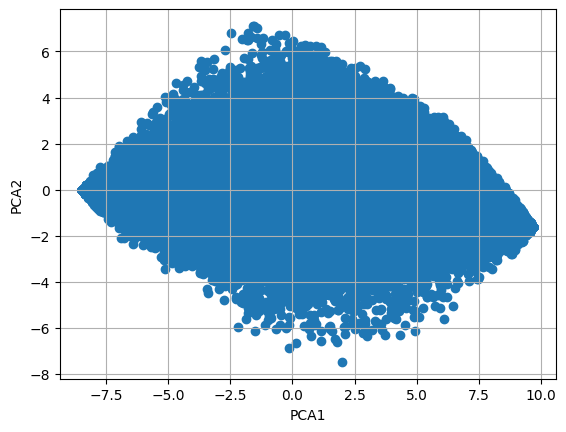

In [ ]:
plt.scatter(numpy_pca[:, 0], numpy_pca[:, 1])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.grid()
plt.show()